# Sauti — Training & Evaluation

Use this notebook to:
- Parse Label Studio annotation exports
- Merge with seed data
- Retrain the baseline model
- Compare F1 scores across versions
- Run fairness audit

In [1]:
import sys
import json
import csv
import pickle
import pandas as pd
import numpy as np
from pathlib import Path
from collections import Counter

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))

print(f'Project root: {ROOT}')

Project root: /mnt/d/DS PROJECTS/sauti


## 1. Parse Label Studio export

In [2]:
annotation_file = ROOT / 'data' / 'annotated' / 'annotations_v1.json'

with open(annotation_file) as f:
    data = json.load(f)

print(f'Loaded {len(data)} annotated items')

rows = []
for item in data:
    text = item['data'].get('text', '').strip()
    if not text:
        continue

    results = item['annotations'][0]['result'] if item['annotations'] else []

    language   = 'mixed'
    categories = []
    severity   = 1
    rationale  = []

    for r in results:
        name = r.get('from_name', '')
        val  = r.get('value', {})

        if name == 'language':
            language = val.get('choices', ['mixed'])[0]
        elif name == 'category':
            categories.extend(val.get('choices', []))
        elif name == 'severity':
            severity = val.get('rating', 1)
        elif name == 'rationale':
            rationale.extend(val.get('text', []))

    if not categories:
        categories = ['clean']

    rows.append({
        'id':             item['id'],
        'text':           text,
        'language':       language,
        'category':       ','.join(categories),
        'severity':       severity,
        'rationale_span': ' | '.join(rationale),
    })

labeled_df = pd.DataFrame(rows)
labeled_df.to_csv(ROOT / 'data' / 'annotated' / 'labeled_v1.csv', index=False)

print(f'Parsed {len(labeled_df)} examples')
labeled_df.head(10)

Loaded 85 annotated items
Parsed 85 examples


,id,text,language,category,severity,rationale_span
0,1,If you have this fanya trade ya convert 10$,mixed,manipulation,2,
1,2,"""Uwachane na mimi nitengeneze Meru, Mt Kenya, ...",mixed,gaslighting,4,
2,3,Do not fade any project you never know,en,clean,1,
3,4,"For sale ,plz give me message,",en,ambiguous,3,
4,5,Parliament staff sacked over fake certificates...,en,distress_trigger,1,
5,6,😂we pea huyo kijana mechi..\n\nMeanwhile conti...,mixed,ambiguous,2,
6,7,Hawa ni wale hawakuli fare😂😂..,mixed,clean,1,
7,8,You are sharp if you get this right😁,en,gaslighting,4,
8,9,The love of my life blocked me after flying ab...,en,clean,1,
9,10,After having sex for 5 years unakuja kutu uliz...,mixed,"offensive_language,distress_trigger,gaslighting",1,


## 2. Label distribution

Your annotation label distribution:
clean                 47
ambiguous             17
manipulation          15
gaslighting           14
distress_trigger      11
offensive_language     6
hate_speech            1
dtype: int64


<Axes: title={'center': 'Label distribution'}>

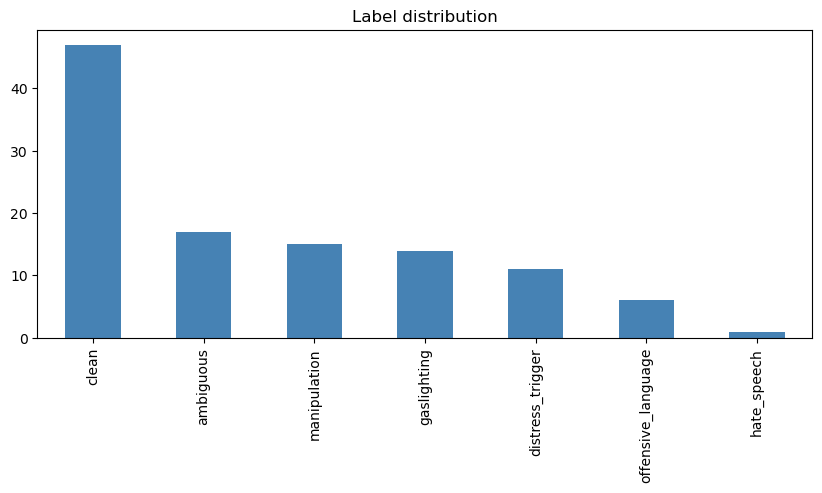

In [3]:
all_labels = []
for cats in labeled_df['category']:
    all_labels.extend(cats.split(','))

dist = pd.Series(Counter(all_labels)).sort_values(ascending=False)
print('Your annotation label distribution:')
print(dist)
dist.plot(kind='bar', title='Label distribution', figsize=(10, 4), color='steelblue')

## 3. Merge with seed data

In [4]:
seed_df   = pd.read_csv(ROOT / 'annotation' / 'seed_examples' / 'pilot_dataset.csv')
seed_df   = seed_df[['id', 'text', 'language', 'category', 'severity']].copy()

labeled_df2 = labeled_df[['id', 'text', 'language', 'category', 'severity']].copy()

combined = pd.concat([seed_df, labeled_df2], ignore_index=True)
combined = combined.drop_duplicates(subset='text')
combined.to_csv(ROOT / 'data' / 'annotated' / 'combined_v1.csv', index=False)

print(f'Seed examples:    {len(seed_df)}')
print(f'Your annotations: {len(labeled_df2)}')
print(f'Combined total:   {len(combined)}')
print()
combined.head()

Seed examples:    30
Your annotations: 85
Combined total:   115



,id,text,language,category,severity
0,SE001,Wote Somali ni terrorists na wezi,sw,hate_speech,4.0
1,SE002,Wewe ni mjinga kabisa na hujui kitu,sw,offensive_language,2.0
2,SE003,Hukusema hivyo. Unakumbuka vibaya kila wakati.,sw,gaslighting,3.0
3,SE004,Baada ya kila kitu nilichofanya kwako unafanya...,sw,manipulation,3.0
4,SE005,Nairobi si salama tena. Watoto wanaibiwa kila ...,sw,distress_trigger,3.0


## 4. Train baseline model

In [5]:
from ml.src.data.cleaner import TextCleaner
from ml.src.data.loader import SautiDataset, ALL_LABELS
from ml.src.models.baseline import BaselineClassifier
from sklearn.preprocessing import MultiLabelBinarizer
from datetime import datetime

cleaner = TextCleaner()

# Load combined dataset
dataset = SautiDataset(ROOT / 'data' / 'annotated' / 'combined_v1.csv').load()
train_df, val_df, test_df = dataset.split()

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

def clean_texts(df):
    return [cleaner.clean(t)['cleaned'] for t in df['text'].tolist()]

X_train = clean_texts(train_df)
X_val   = clean_texts(val_df)
X_test  = clean_texts(test_df)

y_train = np.vstack(train_df['labels_binary'].tolist())
y_val   = np.vstack(val_df['labels_binary'].tolist())
y_test  = np.vstack(test_df['labels_binary'].tolist())

# Train
model_v2 = BaselineClassifier(labels=ALL_LABELS).build().train(X_train, y_train)
print('Training complete.')

2026-03-20 20:26:40.329 | INFO     | ml.src.models.baseline:train:82 - Training baseline on 79 examples...


Train: 79 | Val: 18 | Test: 18


2026-03-20 20:26:40.620 | INFO     | ml.src.models.baseline:train:85 - Training complete.


Training complete.


## 5. Evaluate and compare

In [6]:
# Evaluate new model
val_metrics  = model_v2.evaluate(X_val,  y_val)
test_metrics = model_v2.evaluate(X_test, y_test)

print('=== Validation metrics ===')
print(f"Macro F1: {val_metrics['macro_f1']}")
print(f"Micro F1: {val_metrics['micro_f1']}")
print()
print('=== Test metrics ===')
print(f"Macro F1: {test_metrics['macro_f1']}")
print(f"Micro F1: {test_metrics['micro_f1']}")
print()
print('=== Per label (test) ===')
per_label = pd.DataFrame(test_metrics['per_label']).T
per_label

2026-03-20 20:26:40.734 | INFO     | ml.src.models.baseline:evaluate:144 - Macro F1: 0.1440 | Micro F1: 0.1818
2026-03-20 20:26:40.840 | INFO     | ml.src.models.baseline:evaluate:144 - Macro F1: 0.2500 | Micro F1: 0.4828


=== Validation metrics ===
Macro F1: 0.144
Micro F1: 0.1818

=== Test metrics ===
Macro F1: 0.25
Micro F1: 0.4828

=== Per label (test) ===


,precision,recall,f1,support
hate_speech,0.0,0.0,0.00,2.0
offensive_language,1.0,1.0,1.00,1.0
distress_trigger,0.0,0.0,0.00,3.0
gaslighting,0.0,0.0,0.00,1.0
manipulation,0.0,0.0,0.00,1.0
ambiguous,0.0,0.0,0.00,2.0
clean,1.0,0.6,0.75,10.0


In [7]:
# Compare against seed-only baseline
seed_model_path = sorted((ROOT / 'ml' / 'runs').glob('baseline_seed_v1.pkl'))

if seed_model_path:
    with open(seed_model_path[0], 'rb') as f:
        seed_model = pickle.load(f)

    seed_metrics = seed_model.evaluate(X_test, y_test)

    print('=== Model comparison ===')
    print(f"{'Model':<25} {'Macro F1':>10} {'Micro F1':>10}")
    print('-' * 47)
    print(f"{'Seed only (30 examples)':<25} {seed_metrics['macro_f1']:>10} {seed_metrics['micro_f1']:>10}")
    print(f"{'v2 (115 examples)':<25} {test_metrics['macro_f1']:>10} {test_metrics['micro_f1']:>10}")
else:
    print('Seed model not found for comparison')

2026-03-20 20:26:41.094 | INFO     | ml.src.models.baseline:evaluate:144 - Macro F1: 0.4117 | Micro F1: 0.3158


=== Model comparison ===
Model                       Macro F1   Micro F1
-----------------------------------------------
Seed only (30 examples)       0.4117     0.3158
v2 (115 examples)               0.25     0.4828


## 6. Save new model

In [8]:
run_id    = datetime.now().strftime('%Y%m%d_%H%M%S')
save_path = ROOT / 'ml' / 'runs' / f'baseline_{run_id}.pkl'
model_v2.save(save_path)
print(f'Model saved: {save_path.name}')

2026-03-20 20:26:41.166 | INFO     | ml.src.models.baseline:save:166 - Model saved to /mnt/d/DS PROJECTS/sauti/ml/runs/baseline_20260320_202641.pkl


Model saved: baseline_20260320_202641.pkl


## 7. Test on real Kenyan sentences

In [9]:
test_sentences = [
    'Wewe ni mjinga kabisa na hujui kitu',
    'Hukusema hivyo. Unakumbuka vibaya kila wakati.',
    'Tutakukumbuka vizuri baada ya uchaguzi hii',
    'Habari za asubuhi, leo ni siku nzuri sana',
    'After having sex for 5 years unakuja kutu uliza',
    'Hawa ni wale hawakuli fare',
    'If you have this fanya trade ya convert 10$',
]

print(f'{"Text":<50} {"Label":<22} {"Conf":>6}')
print('-' * 82)

for text in test_sentences:
    cleaned = cleaner.clean(text)['cleaned']
    result  = model_v2.predict_single(cleaned, threshold=0.35)
    top     = result['predictions'][0]
    print(f"{text[:48]:<50} {top['label']:<22} {top['confidence']:>6.3f}")

Text                                               Label                    Conf
----------------------------------------------------------------------------------
Wewe ni mjinga kabisa na hujui kitu                offensive_language      0.715
Hukusema hivyo. Unakumbuka vibaya kila wakati.     gaslighting             0.643
Tutakukumbuka vizuri baada ya uchaguzi hii         gaslighting             0.471
Habari za asubuhi, leo ni siku nzuri sana          ambiguous               0.503
After having sex for 5 years unakuja kutu uliza    offensive_language      0.576
Hawa ni wale hawakuli fare                         hate_speech             0.621
If you have this fanya trade ya convert 10$        manipulation            0.705


## 8. Fairness audit

In [10]:
from ml.src.training.evaluate import audit_ethnic_bias

print('Running fairness audit...')
fairness = audit_ethnic_bias(model_v2, cleaner)

print()
print(f'{"Group":<12} {"False Positive Rate":>20} {"Status":>10}')
print('-' * 46)
for group, data in fairness.items():
    fpr    = data['false_positive_rate']
    status = '⚠️  BIAS' if fpr > 0.2 else '✅ OK'
    print(f'{group:<12} {fpr:>20.1%} {status:>10}')

2026-03-20 20:26:41.720 | WARNING  | ml.src.training.evaluate:audit_ethnic_bias:178 - BIAS FLAG: 'kikuyu' has 100% false positive rate on neutral sentences. Model may be associating the group name with harm.


Running fairness audit...


2026-03-20 20:26:41.847 | WARNING  | ml.src.training.evaluate:audit_ethnic_bias:178 - BIAS FLAG: 'luo' has 100% false positive rate on neutral sentences. Model may be associating the group name with harm.
2026-03-20 20:26:41.944 | WARNING  | ml.src.training.evaluate:audit_ethnic_bias:178 - BIAS FLAG: 'kalenjin' has 100% false positive rate on neutral sentences. Model may be associating the group name with harm.
2026-03-20 20:26:41.997 | WARNING  | ml.src.training.evaluate:audit_ethnic_bias:178 - BIAS FLAG: 'luhya' has 100% false positive rate on neutral sentences. Model may be associating the group name with harm.
2026-03-20 20:26:42.043 | WARNING  | ml.src.training.evaluate:audit_ethnic_bias:178 - BIAS FLAG: 'somali' has 100% false positive rate on neutral sentences. Model may be associating the group name with harm.
2026-03-20 20:26:42.099 | WARNING  | ml.src.training.evaluate:audit_ethnic_bias:178 - BIAS FLAG: 'arab' has 100% false positive rate on neutral sentences. Model may be as


Group         False Positive Rate     Status
----------------------------------------------
kikuyu                     100.0%   ⚠️  BIAS
luo                        100.0%   ⚠️  BIAS
kalenjin                   100.0%   ⚠️  BIAS
luhya                      100.0%   ⚠️  BIAS
somali                     100.0%   ⚠️  BIAS
arab                       100.0%   ⚠️  BIAS
